In [1]:
import pandas as pd

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\fatality rate_variables_GTD.xlsx"

# Read both sheets
nkill_df = pd.read_excel(file_path, sheet_name="nkill")
nwound_df = pd.read_excel(file_path, sheet_name="nwound")



In [2]:
# Convert nkill
nkill_long = nkill_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nkill"
)

# Convert nwound
nwound_long = nwound_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nwound"
)

In [3]:
panel_df = pd.merge(
    nkill_long,
    nwound_long,
    on=["Country", "Year"],
    how="inner"
)

In [4]:
panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(by=["Country", "Year"])

In [5]:
# Avoid division by zero
panel_df["fatality_rate"] = panel_df["nkill"] / (panel_df["nkill"] + panel_df["nwound"])

# Handle cases where nkill + nwound = 0
panel_df["fatality_rate"] = panel_df["fatality_rate"].fillna(0)

In [6]:

panel_df

,Country,Year,nkill,nwound,fatality_rate
0,Afghanistan,1970,NaN,NaN,0.000000
204,Afghanistan,1971,NaN,NaN,0.000000
408,Afghanistan,1972,NaN,NaN,0.000000
612,Afghanistan,1973,0.0,1.0,0.000000
816,Afghanistan,1974,NaN,NaN,0.000000
...,...,...,...,...,...
9383,Zimbabwe,2016,NaN,NaN,0.000000
9587,Zimbabwe,2017,0.0,1.0,0.000000
9791,Zimbabwe,2018,2.0,47.0,0.040816
9995,Zimbabwe,2019,0.0,0.0,0.000000


In [7]:
import pandas as pd
from functools import reduce

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\WGI_fatality_1.xlsx"

xls = pd.ExcelFile(file_path)
dfs = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    # Rename 'value' to indicator name (sheet name)
    df.rename(columns={"value": sheet.lower()}, inplace=True)
    
    # Keep required columns
    df = df[["Country", "Year", sheet.lower()]]
    
    # Clean data
    df["Country"] = df["Country"].str.strip().str.lower()
    df["Year"] = df["Year"].astype(int)
    
    # Ensure uniqueness (VERY IMPORTANT)
    df = df.drop_duplicates(subset=["Country", "Year"])
    
    dfs.append(df)

# Merge all sheets
wgi_merged = reduce(
    lambda left, right: pd.merge(left, right, on=["Country", "Year"], how="inner"),
    dfs
)

# Sort
wgi_merged = wgi_merged.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Check
print(wgi_merged.shape)
print(wgi_merged.head())

(4973, 8)
       Country  Year  voice and accountability  political stability  \
0  afghanistan  1996                    0.0625               0.0625   
1  afghanistan  1998                    0.0625               0.0625   
2  afghanistan  2000                    0.0625               0.0625   
3  afghanistan  2002                    0.1875               0.0625   
4  afghanistan  2003                    0.2500               0.1250   

   government effectiveness  regulatory quality  rule of law  \
0                     0.000            0.000000       0.1875   
1                     0.000            0.000000       0.1875   
2                     0.000            0.000000       0.1875   
3                     0.125            0.166667       0.1875   
4                     0.125            0.250000       0.1875   

   control of corruption  
0                  0.000  
1                  0.000  
2                  0.000  
3                  0.125  
4                  0.125  


In [8]:
# Ensure same format before merging

# Clean panel_df (terrorism data)
panel_df["Country"] = panel_df["Country"].astype(str).str.strip().str.lower()
panel_df["Year"] = panel_df["Year"].astype(int)

# Clean WGI data
wgi_merged["Country"] = wgi_merged["Country"].astype(str).str.strip().str.lower()
wgi_merged["Year"] = wgi_merged["Year"].astype(int)

# Merge
final_df = pd.merge(
    panel_df,
    wgi_merged,
    on=["Country", "Year"],
    how="left"   # 🔥 recommended
)

In [9]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': final_df.isna().sum(),
    'Zero_Count': (final_df == 0).sum(),
    'Total_Values': final_df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0         10200   0.000000   
Year                              0           0         10200   0.000000   
nkill                          6179        1247         10200  60.578431   
nwound                         6212        1199         10200  60.901961   
fatality_rate                     0        7459         10200   0.000000   
voice and accountability       6897          95         10200  67.617647   
political stability            6897          42         10200  67.617647   
government effectiveness       6897         667         10200  67.617647   
regulatory quality             6897          20         10200  67.617647   
rule of law                    6897           0         10200  67.617647   
control of corruption          6897         519         10200  67.617647   

                             Zero_%  
Country                    0.000000  
Year       

In [10]:
df=final_df.copy()
df

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption
0,afghanistan,1970,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,afghanistan,1971,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,afghanistan,1972,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,afghanistan,1973,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,afghanistan,1974,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.0,0.107143,0.125,0.0
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.0,0.107143,0.100,0.0
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.0,0.107143,0.150,0.0
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.0,0.107143,0.125,0.0


In [11]:
#Basic cleaning
cols = ['fatality_rate', 'voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=cols)

# Log transform (important)
import numpy as np
df['log_fatality_rate'] = np.log1p(df['fatality_rate'])

df

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\24402739.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_fatality_rate'] = np.log1p(df['fatality_rate'])


,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
25,afghanistan,1996,31.0,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.410915
27,afghanistan,1998,8.0,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.191055
29,afghanistan,2000,38.0,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.574088
31,afghanistan,2002,74.0,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125,0.181872
32,afghanistan,2003,163.0,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125,0.383253
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.000,0.107143,0.1250,0.000,0.000000
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.000,0.107143,0.1000,0.000,0.000000
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000,0.040005
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.000,0.107143,0.1250,0.000,0.000000


DESCRIPTIVE ANALYSIS

In [12]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': df.isna().sum(),
    'Zero_Count': (df == 0).sum(),
    'Total_Values': df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0          3303   0.000000   
Year                              0           0          3303   0.000000   
nkill                          1737         499          3303  52.588556   
nwound                         1754         409          3303  53.103239   
fatality_rate                     0        2250          3303   0.000000   
voice and accountability          0          95          3303   0.000000   
political stability               0          42          3303   0.000000   
government effectiveness          0         667          3303   0.000000   
regulatory quality                0          20          3303   0.000000   
rule of law                       0           0          3303   0.000000   
control of corruption             0         519          3303   0.000000   
log_fatality_rate                 0        2250          3303   0.000000   

           

In [13]:
df[cols + ['log_fatality_rate']].describe()

,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
count,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000
mean,0.150806,0.484401,0.586630,0.390772,0.511076,0.506985,0.368951,0.117803
std,0.271987,0.266143,0.248905,0.297224,0.231398,0.246907,0.277941,0.202222
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.025000,0.000000,0.000000
25%,0.000000,0.264500,0.437500,0.250000,0.357143,0.325000,0.125000,0.000000
50%,0.000000,0.469333,0.565657,0.250000,0.500000,0.475000,0.250000,0.000000
75%,0.225978,0.723167,0.812500,0.500000,0.714286,0.700000,0.500000,0.203738
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.693147


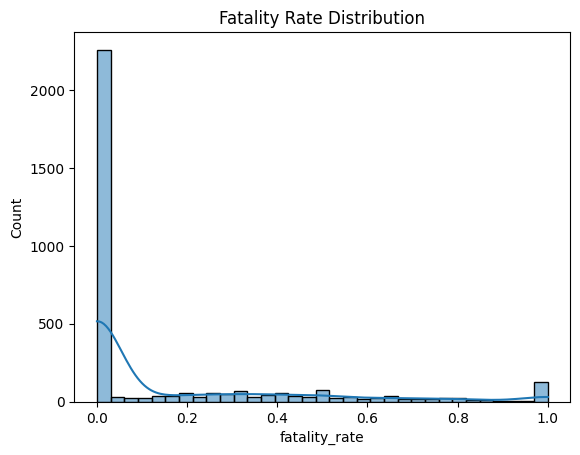

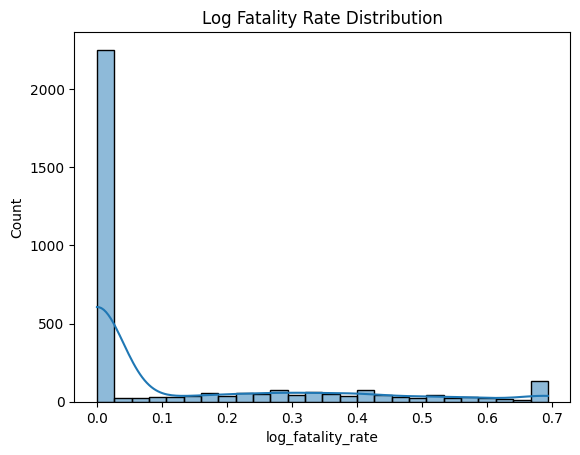

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution")
plt.show()

sns.histplot(df['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution")
plt.show()

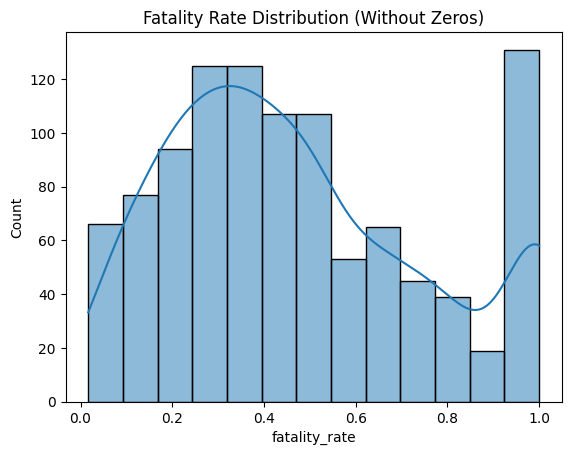

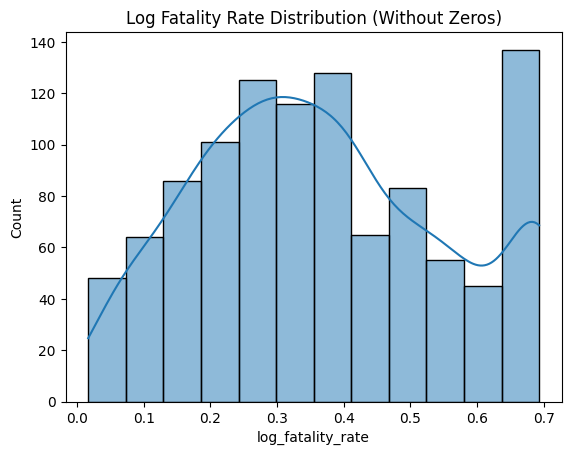

In [15]:
df_no_zero = df[df['fatality_rate'] > 0]

import seaborn as sns
import matplotlib.pyplot as plt

# Fatality Rate (no zeros)
sns.histplot(df_no_zero['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution (Without Zeros)")
plt.show()

# Log Fatality Rate (no zeros)
sns.histplot(df_no_zero['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution (Without Zeros)")
plt.show()

Right-skewed distribution → most values are low–moderate, few very high fatality cases

Major concentration (0.2–0.5) → typical events have moderate fatality rates

High-value clustering near 1 → presence of extreme lethal incidents

Non-normal data → violates OLS assumptions, suggests need for transformation

Outliers present → extreme events may bias results

Model implication → use log transformation and non-linear/robust models

Zeros removed → focuses on active events, improves distribution clarity

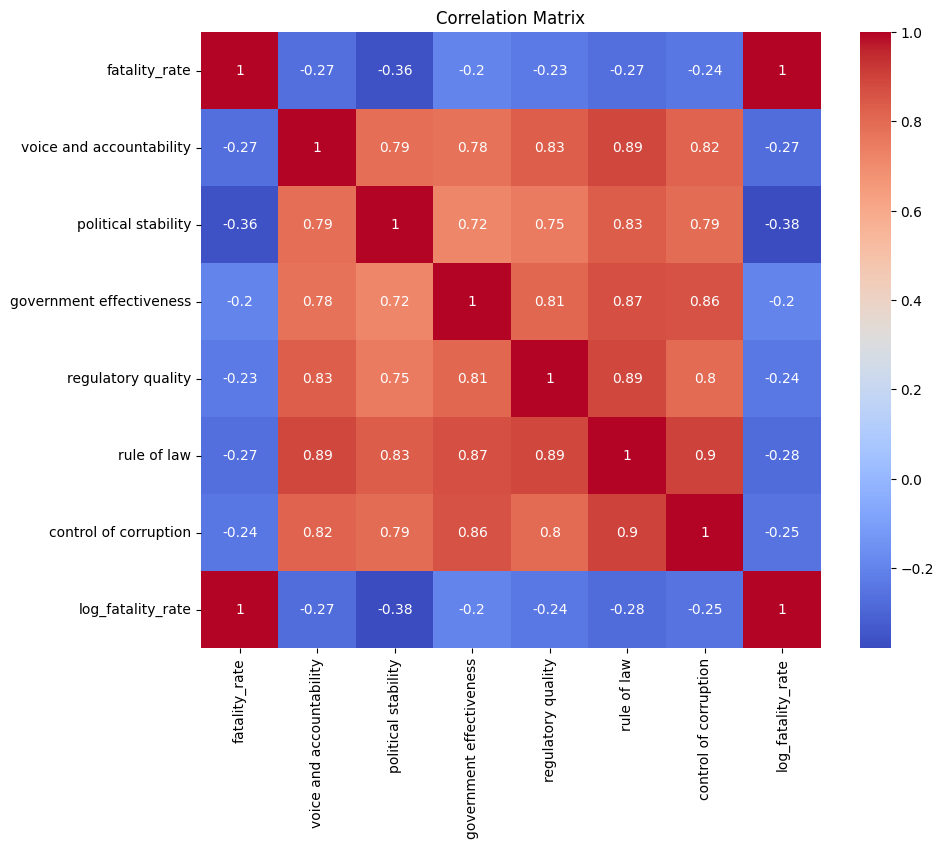

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df[cols + ['log_fatality_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Weak–moderate negative correlation with fatality_rate (≈ -0.2 to -0.36) → better governance is associated with lower fatality rates

Strong positive correlation among WGI indicators (≈ 0.72 to 0.90) → indicators move together, reflecting overall governance quality

High multicollinearity present → variables like rule of law, regulatory quality, control of corruption are highly correlated

Political stability shows strongest negative link (~ -0.36 to -0.38) → most influential in reducing fatalities

Log transformation does not change relationships → similar correlations with log_fatality_rate

Model implication → avoid using all WGI variables together; use:

PCA / index creation, or

drop/select key variables, or

regularization (LASSO/Ridge)

Conclusion → governance matters, but effects are joint and interdependent, not isolated

<Axes: >

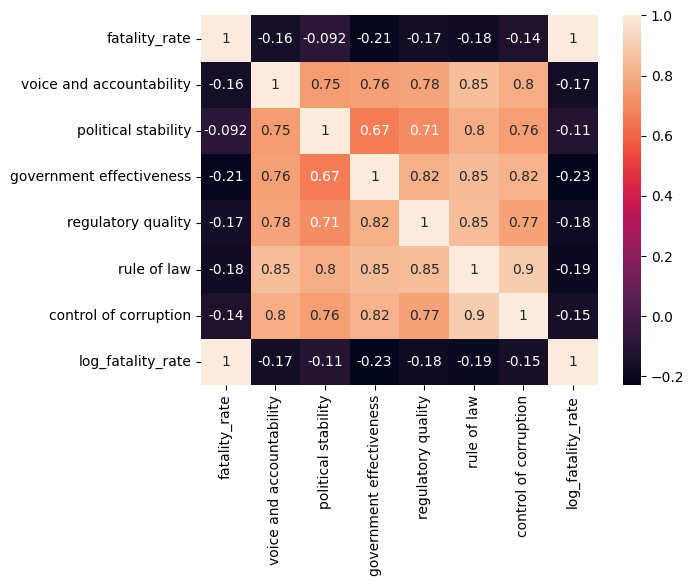

In [17]:
import seaborn as sns
sns.heatmap(df_no_zero[cols + ['log_fatality_rate']].corr(), annot=True)

INFERENTIAL ANALYSIS

In [35]:
#Normality Test
from scipy.stats import shapiro

shapiro(df['log_fatality_rate'])

ShapiroResult(statistic=np.float64(0.6391529112439116), pvalue=np.float64(4.189406893000716e-64))

Shapiro–Wilk test statistic = 0.639 → far from 1, indicating strong deviation from normality

p-value ≈ 0 (4.19e-64) → reject null hypothesis of normality at any significance level

Conclusion → fatality_rate is not normally distributed

Implication for modeling:
OLS assumptions violated
Use log transformation / robust methods / non-parametric approaches

Supports earlier finding → skewed distribution seen in histogram is statistically confirmed

In [19]:
#Normality Test
from scipy.stats import shapiro

shapiro(df_no_zero['log_fatality_rate'])

ShapiroResult(statistic=np.float64(0.958414563736066), pvalue=np.float64(9.863047911859443e-17))

In [20]:
#Group Comparison (optional but strong)
df['governance_index'] = df[
    ['voice and accountability', 'political stability',
     'government effectiveness', 'regulatory quality',
     'rule of law', 'control of corruption']
].mean(axis=1)

df['gov_group'] = pd.qcut(df['governance_index'], 3, labels=['Low','Medium','High'])

#ANOVA
from scipy.stats import f_oneway

groups = [g['log_fatality_rate'].values for _, g in df.groupby('gov_group')]
f_oneway(*groups)

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2940020813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['governance_index'] = df[
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2940020813.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gov_group'] = pd.qcut(df['governance_index'], 3, labels=['Low','Medium','High'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2940020813.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

F_onewayResult(statistic=np.float64(170.91696184181203), pvalue=np.float64(2.3430128629883435e-71))

F-statistic = 170.92 → indicates large variation between group means

p-value ≈ 0 (2.34e-71) → reject null hypothesis of equal means

Conclusion → there are statistically significant differences in fatality_rate across groups

Interpretation → at least one group has a different mean fatality rate
Implication:

grouping variable (e.g., country/cluster) is important
supports use of fixed effects / clustering / group-based models

Next step → perform post-hoc tests (Tukey HSD) to identify which groups differ

In [37]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.cluster import KMeans

X = df[['voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']]

kmeans = KMeans(n_clusters=4, random_state=42)
df['group'] = kmeans.fit_predict(X)

tukey = pairwise_tukeyhsd(
    endog=df['fatality_rate'],   # dependent variable
    groups=df['group'],          # grouping variable
    alpha=0.05
)

print(tukey)

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2738092679.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group'] = kmeans.fit_predict(X)


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.1047    0.0  0.0709  0.1386   True
     0      2  -0.0039 0.9936 -0.0421  0.0343  False
     0      3   0.1933    0.0  0.1573  0.2293   True
     1      2  -0.1086    0.0 -0.1411 -0.0761   True
     1      3   0.0886    0.0  0.0586  0.1185   True
     2      3   0.1972    0.0  0.1624  0.2319   True
----------------------------------------------------


Significant differences across clusters → most groups have different mean fatality rates (p ≈ 0)

Group 0 vs 2 not significant → these clusters show similar fatality levels

Group 3 is clearly distinct → differs significantly from all others

Large mean gaps (~0.19–0.20) → differences are practically meaningful

Conclusion → WGI-based clusters capture real variation in fatality rates, showing governance matters

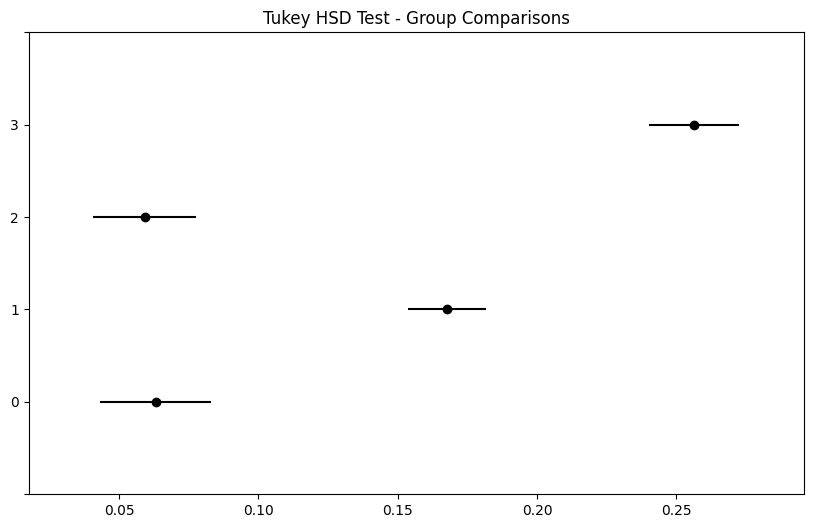

In [38]:
tukey.plot_simultaneous()
plt.title("Tukey HSD Test - Group Comparisons")
plt.show()

Most confidence intervals do not overlap → confirms significant differences between groups

Group 3 is farthest apart → clearly distinct from other clusters

Group 0 and Group 2 appear closer → aligns with earlier result of no significant difference

Magnitude of separation varies → some groups have larger effect sizes than others

Conclusion → visualization supports Tukey results, showing clear group-wise variation in fatality rates

In [41]:
import pandas as pd

# Create 4 quantile-based groups
df_no_zero['severity_group'] = pd.qcut(
    df_no_zero['fatality_rate'],
    q=4,
    labels=['Low', 'Moderate', 'High', 'Severe'],
    duplicates='drop'
)

# Check distribution
print(df_no_zero['severity_group'].value_counts())

print(df_no_zero.groupby('severity_group')['fatality_rate'].describe())

severity_group
High        277
Low         268
Moderate    259
Severe      249
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2543266833.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_no_zero.groupby('severity_group')['fatality_rate'].describe())


                count      mean       std       min       25%       50%  \
severity_group                                                            
Low             268.0  0.153533  0.068110  0.016746  0.094851  0.166667   
Moderate        259.0  0.337137  0.046787  0.252448  0.298441  0.333333   
High            277.0  0.532148  0.074729  0.416667  0.471698  0.506579   
Severe          249.0  0.892536  0.118616  0.667862  0.776316  0.971698   

                     75%       max  
severity_group                      
Low             0.206897  0.250000  
Moderate        0.380119  0.415842  
High            0.600000  0.666667  
Severe          1.000000  1.000000  


In [43]:
from scipy.stats import f_oneway

groups = [
    group['political stability'].values
    for name, group in df_no_zero.groupby('severity_group')
]

f_stat, p_val = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_no_zero['political stability'],
    groups=df_no_zero['severity_group'],
    alpha=0.05
)

print(tukey)

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\3532044314.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group')


F-statistic: 9.904161343254303
p-value: 1.924299753429433e-06
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
    High      Low   0.0958    0.0  0.0437   0.148   True
    High Moderate   0.0119 0.9378 -0.0407  0.0645  False
    High   Severe   0.0039 0.9975 -0.0492  0.0571  False
     Low Moderate   -0.084 0.0003  -0.137 -0.0309   True
     Low   Severe  -0.0919 0.0001 -0.1455 -0.0383   True
Moderate   Severe  -0.0079 0.9816 -0.0619  0.0461  False
--------------------------------------------------------


ANOVA significant (F = 9.90, p ≈ 0) → governance indicator differs across severity groups

Low severity group is clearly different → significantly lower/higher (depending on variable) than:
High
Moderate
Severe

High, Moderate, and Severe are NOT significantly different → these groups show similar governance levels

Largest differences involve Low group (~0.08–0.09) → indicates clear separation from others

No difference among higher severity levels → suggests governance does not vary much once violence crosses a threshold

Conclusion → governance differences are mainly between low vs higher severity, not within high-severity categories

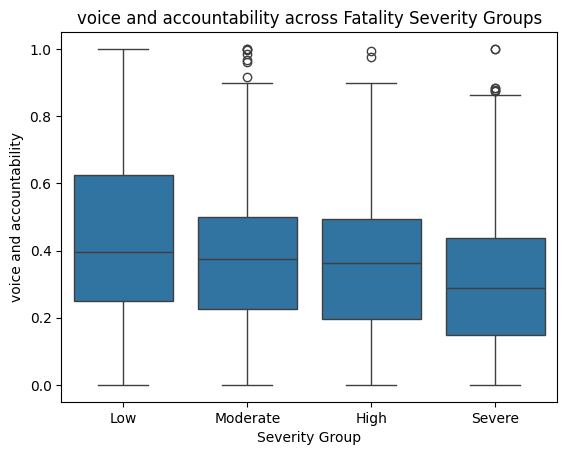

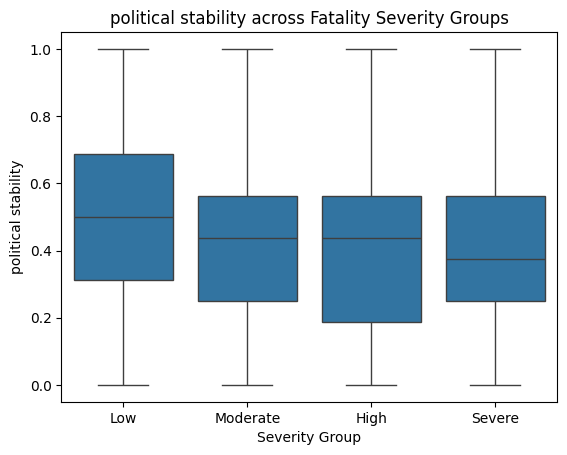

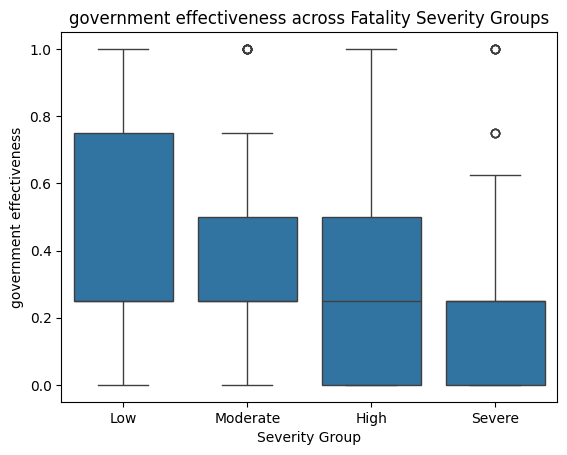

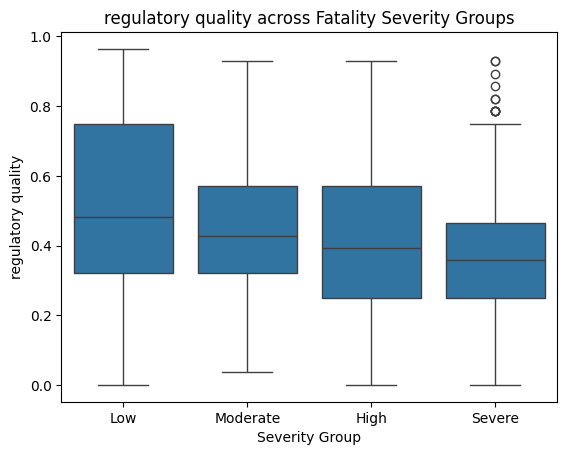

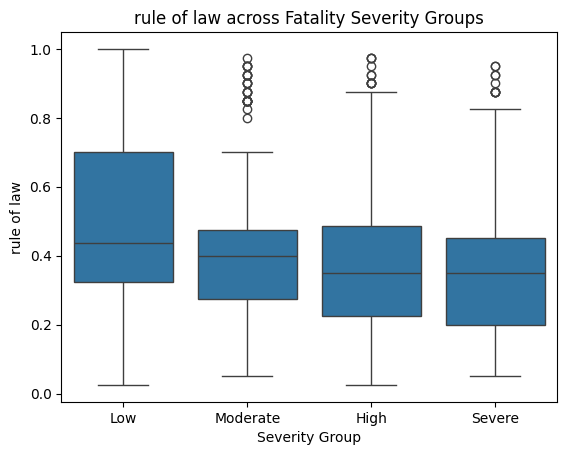

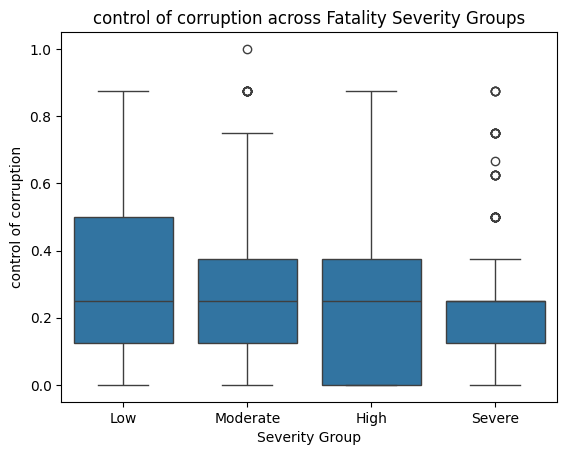

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

wgi_vars = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

for var in wgi_vars:
    plt.figure()
    sns.boxplot(x='severity_group', y=var, data=df_no_zero)
    plt.title(f"{var} across Fatality Severity Groups")
    plt.xlabel("Severity Group")
    plt.ylabel(var)
    plt.show()

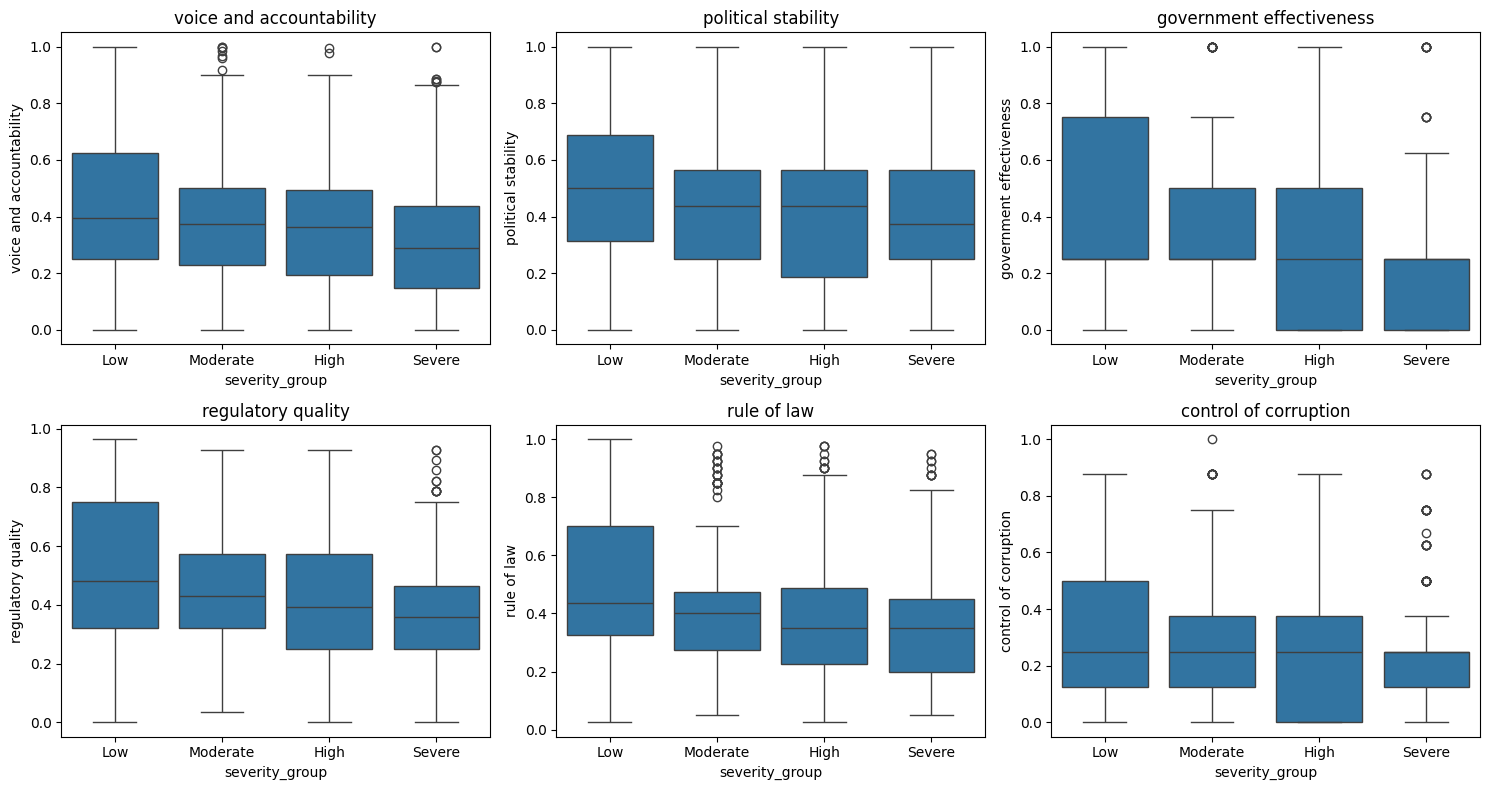

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(wgi_vars):
    ax = axes[i//3, i%3]
    sns.boxplot(x='severity_group', y=var, data=df_no_zero, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
from scipy import stats
from scipy.stats import levene, f_oneway, kruskal

# Governance variables
wgi_vars = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

# Function to format p-values
def format_p(p):
    if p < 0.001:
        return f"< 0.001 ({p:.2e})"
    else:
        return f"{p:.4f}"

for var in wgi_vars:
    print("\n" + "="*65)
    print(f"🔹 Analysis for: {var.upper()}")
    print("="*65)
    
    # Store group data
    group_data = []
    normal_flag = True
    
    # ---------------------------
    # 1. Shapiro Test
    # ---------------------------
    print("\nNormality Test (Shapiro-Wilk):")
    
    for name, group in df_no_zero.groupby('severity_group'):
        data = group[var].dropna()
        stat, p = stats.shapiro(data)
        
        if p < 0.05:
            normal_flag = False
        
        print(f"{name:<10} → p = {format_p(p)}")
        group_data.append(data)
    
    # ---------------------------
    # 2. Levene Test
    # ---------------------------
    lev_stat, lev_p = levene(*group_data)
    print(f"\nLevene Test (Equal Variance): p = {format_p(lev_p)}")
    
    # ---------------------------
    # 3. ANOVA
    # ---------------------------
    f_stat, f_p = f_oneway(*group_data)
    print(f"ANOVA Result: p = {format_p(f_p)}")
    
    # ---------------------------
    # 4. Kruskal-Wallis
    # ---------------------------
    k_stat, k_p = kruskal(*group_data)
    print(f"Kruskal-Wallis Result: p = {format_p(k_p)}")
    
    # ---------------------------
    # 5. Final Decision
    # ---------------------------
    print("\nFinal Decision:")
    
    if normal_flag and lev_p > 0.05:
        print("→ Use ANOVA (assumptions satisfied)")
    else:
        print("→ Use Kruskal-Wallis (non-parametric preferred)")
    
    # ---------------------------
    # 6. Significance Conclusion
    # ---------------------------
    if k_p < 0.05:
        print("→ Significant differences exist across severity groups")
    else:
        print("→ No significant differences across groups")


🔹 Analysis for: VOICE AND ACCOUNTABILITY

Normality Test (Shapiro-Wilk):


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\1149786037.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group'):


Low        → p = < 0.001 (8.06e-07)
Moderate   → p = < 0.001 (1.01e-06)
High       → p = < 0.001 (3.08e-07)
Severe     → p = < 0.001 (1.12e-07)

Levene Test (Equal Variance): p = < 0.001 (7.65e-05)
ANOVA Result: p = < 0.001 (5.43e-08)
Kruskal-Wallis Result: p = < 0.001 (8.28e-07)

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ Significant differences exist across severity groups

🔹 Analysis for: POLITICAL STABILITY

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (1.88e-05)
Moderate   → p = < 0.001 (7.14e-05)
High       → p = < 0.001 (2.87e-06)
Severe     → p = < 0.001 (9.15e-05)

Levene Test (Equal Variance): p = 0.0170
ANOVA Result: p = < 0.001 (1.92e-06)
Kruskal-Wallis Result: p = < 0.001 (1.50e-05)

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ Significant differences exist across severity groups

🔹 Analysis for: GOVERNMENT EFFECTIVENESS

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (7.18e-14)
Moderate   → p = < 0.001 (6.72e

Normality assumption violated across all groups and variables → Shapiro–Wilk test shows p < 0.001 consistently, indicating strong non-normality

Homogeneity of variance not satisfied → Levene test significant in most cases → unequal group variances

Kruskal–Wallis test significant for all variables (p < 0.001) → confirms statistically significant differences in governance indicators across severity groups

Consistency across all WGI indicators → results are robust and not variable-specific

ANOVA also significant but less reliable → due to violation of assumptions, non-parametric results are preferred

REGRESSION ANALYSIS

In [23]:
#OLS regression
import statsmodels.api as sm

X = df[['voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']]

X = sm.add_constant(X)
y = df['log_fatality_rate']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     100.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          6.97e-117
Time:                        03:17:31   Log-Likelihood:                 871.68
No. Observations:                3303   AIC:                            -1729.
Df Residuals:                    3296   BIC:                            -1687.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [24]:
#OLS regression
import statsmodels.api as sm

X = df_no_zero[['voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']]

X = sm.add_constant(X)
y = df_no_zero['log_fatality_rate']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     11.52
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.64e-12
Time:                        03:17:31   Log-Likelihood:                 301.27
No. Observations:                1053   AIC:                            -588.5
Df Residuals:                    1046   BIC:                            -553.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [25]:
#Multicollienarity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    feature       VIF
0                     const  7.661103
1  voice and accountability  4.056555
2       political stability  3.059385
3  government effectiveness  4.356917
4        regulatory quality  4.270061
5               rule of law  9.662137
6     control of corruption  5.743719


In [30]:
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df_no_zero[['voice and accountability', 'political stability',
               'government effectiveness', 'regulatory quality',
               'rule of law', 'control of corruption']]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=1)
df_no_zero['governance_pca'] = pca.fit_transform(scaled)

X_pca = sm.add_constant(df_no_zero['governance_pca'])
model_pca = sm.OLS(y, X_pca).fit()
print(model_pca.summary())

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2105881132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_zero['governance_pca'] = pca.fit_transform(scaled)


                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     39.54
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.70e-10
Time:                        03:20:09   Log-Likelihood:                 287.03
No. Observations:                1053   AIC:                            -570.1
Df Residuals:                    1051   BIC:                            -560.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3695      0.006     65.

PANEL DATA ANALYSIS (VERY IMPORTANT 🔥)

In [31]:
#Fixed Effects Model
from linearmodels.panel import PanelOLS

df_no_zero = df_no_zero.set_index(['Country', 'Year'])

X = df_no_zero[['governance_pca']]
y = df_no_zero['log_fatality_rate']

model_fe = PanelOLS(y, X, entity_effects=True)
fe_res = model_fe.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:      log_fatality_rate   R-squared:                        0.0028
Estimator:                   PanelOLS   R-squared (Between):              0.0219
No. Observations:                1053   R-squared (Within):               0.0028
Date:                Fri, Mar 27 2026   R-squared (Overall):             -0.0187
Time:                        03:21:08   Log-likelihood                    512.52
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.6105
Entities:                         129   P-value                           0.1065
Avg Obs:                       8.1628   Distribution:                   F(1,923)
Min Obs:                       1.0000                                           
Max Obs:                       22.000   F-statistic (robust):             2.6105
                            

In [32]:
#Random Effects Model
from linearmodels.panel import RandomEffects

model_re = RandomEffects(y, X)
re_res = model_re.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:      log_fatality_rate   R-squared:                        0.0052
Estimator:              RandomEffects   R-squared (Between):              0.0253
No. Observations:                1053   R-squared (Within):               0.0026
Date:                Fri, Mar 27 2026   R-squared (Overall):             -0.0252
Time:                        03:21:18   Log-likelihood                    443.84
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.4864
Entities:                         129   P-value                           0.0194
Avg Obs:                       8.1628   Distribution:                  F(1,1052)
Min Obs:                       1.0000                                           
Max Obs:                       22.000   F-statistic (robust):             5.4864
                            

In [33]:
#Hausman Test
from linearmodels.panel import compare

compare({'FE': fe_res, 'RE': re_res})

,FE,RE
Dep. Variable,log_fatality_rate,log_fatality_rate
Estimator,PanelOLS,RandomEffects
No. Observations,1053,1053
Cov. Est.,Unadjusted,Unadjusted
R-squared,0.0028,0.0052
R-Squared (Within),0.0028,0.0026
R-Squared (Between),0.0219,0.0253
R-Squared (Overall),-0.0187,-0.0252
F-statistic,2.6105,5.4864
P-value (F-stat),0.1065,0.0194
